In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pgeocode
import numpy as np
import statsmodels.formula.api as smf

### Get AQI Data

In [2]:
df = pd.read_csv("data/aqi_data.csv")
df

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2021,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
1,01/02/2021,AQS,60730001,1,0.038,ppm,35,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
2,01/03/2021,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
3,01/04/2021,AQS,60730001,1,0.039,ppm,36,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
4,01/05/2021,AQS,60730001,1,0.034,ppm,31,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14484,12/05/2025,AirNow,60739991,1,0.046,ppm,43,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14485,12/06/2025,AirNow,60739991,1,0.047,ppm,44,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14486,12/07/2025,AirNow,60739991,1,0.042,ppm,39,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410
14487,12/08/2025,AirNow,60739991,1,0.045,ppm,42,La Posta Band of Indians,24,100.0,...,Ozone,NaN,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.725189,-116.364410


In [3]:
df.describe()

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,1.448900e+04,14489.0,14489.000000,14489.000000,14489.000000,14489.000000,14489.0,12315.000000,14489.0,14489.0,14489.0,14489.000000,14489.000000
mean,6.073153e+07,1.0,0.044117,42.953965,17.634343,97.703430,44201.0,52.310597,41740.0,6.0,73.0,32.860506,-117.008677
std,2.288300e+03,0.0,0.010467,15.529692,2.651911,6.411864,0.0,13.573371,0.0,0.0,0.0,0.251168,0.241643
min,6.073000e+07,1.0,0.000000,0.000000,13.000000,71.000000,44201.0,47.000000,41740.0,6.0,73.0,32.578165,-117.396249
25%,6.073101e+07,1.0,0.038000,35.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.710177,-117.123964
50%,6.073102e+07,1.0,0.044000,41.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.789565,-117.059088
75%,6.073103e+07,1.0,0.050000,46.000000,17.000000,100.000000,44201.0,47.000000,41740.0,6.0,73.0,32.845709,-116.921374
max,6.073999e+07,1.0,0.090000,161.000000,24.000000,100.000000,44201.0,87.000000,41740.0,6.0,73.0,33.362593,-116.364410


In [4]:
df['Local Site Name'].unique()


array(['Chula Vista', 'Alpine', 'Camp Pendleton', 'Donovan',
       'San Diego - Kearny Villa Rd.',
       'El Cajon - Lexington Elementary School',
       'San Diego - Sherman Elementary School', 'Pala Airpad',
       'La Posta Band of Indians'], dtype=object)

In [5]:
df['Site ID'].nunique()

9

In [6]:
df['CBSA Name'].unique()

array(['San Diego-Carlsbad, CA'], dtype=object)

In [7]:
df.isna().sum()

Date                                       0
Source                                     0
Site ID                                    0
POC                                        0
Daily Max 8-hour Ozone Concentration       0
Units                                      0
Daily AQI Value                            0
Local Site Name                            0
Daily Obs Count                            0
Percent Complete                           0
AQS Parameter Code                         0
AQS Parameter Description                  0
Method Code                             2174
CBSA Code                                  0
CBSA Name                                  0
State FIPS Code                            0
State                                      0
County FIPS Code                           0
County                                     0
Site Latitude                              0
Site Longitude                             0
dtype: int64

In [8]:
df.value_counts('Local Site Name')

Local Site Name
San Diego - Sherman Elementary School     1766
Alpine                                    1761
San Diego - Kearny Villa Rd.              1759
Donovan                                   1747
Camp Pendleton                            1681
Pala Airpad                               1635
El Cajon - Lexington Elementary School    1609
Chula Vista                               1563
La Posta Band of Indians                   968
Name: count, dtype: int64

In [9]:
df.value_counts('Date')

Date
04/05/2024    9
04/24/2023    9
04/21/2023    9
04/21/2024    9
04/22/2023    9
             ..
08/20/2025    5
09/27/2025    5
09/22/2022    5
01/25/2021    5
09/24/2021    4
Name: count, Length: 1800, dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df.groupby("Local Site Name").resample("D", on="Date")["Daily AQI Value"].mean()

Local Site Name                        Date      
Alpine                                 2021-01-01    39.0
                                       2021-01-02    42.0
                                       2021-01-03    42.0
                                       2021-01-04    40.0
                                       2021-01-05    40.0
                                                     ... 
San Diego - Sherman Elementary School  2025-12-05    30.0
                                       2025-12-06    35.0
                                       2025-12-07    34.0
                                       2025-12-08    34.0
                                       2025-12-09    25.0
Name: Daily AQI Value, Length: 15316, dtype: float64

In [12]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

In [13]:
stations_per_day = df.groupby('Date')['Local Site Name'].nunique()
stations_per_day.describe()

count    1800.000000
mean        8.049444
std         0.850269
min         4.000000
25%         8.000000
50%         8.000000
75%         9.000000
max         9.000000
Name: Local Site Name, dtype: float64

In [14]:
pivot = df.pivot_table(
    index='Date',
    columns='Local Site Name',
    values='Daily AQI Value'
)

In [15]:
pivot['County Mean AQI'] = pivot.mean(axis=1)


Text(0, 0.5, 'AQI')

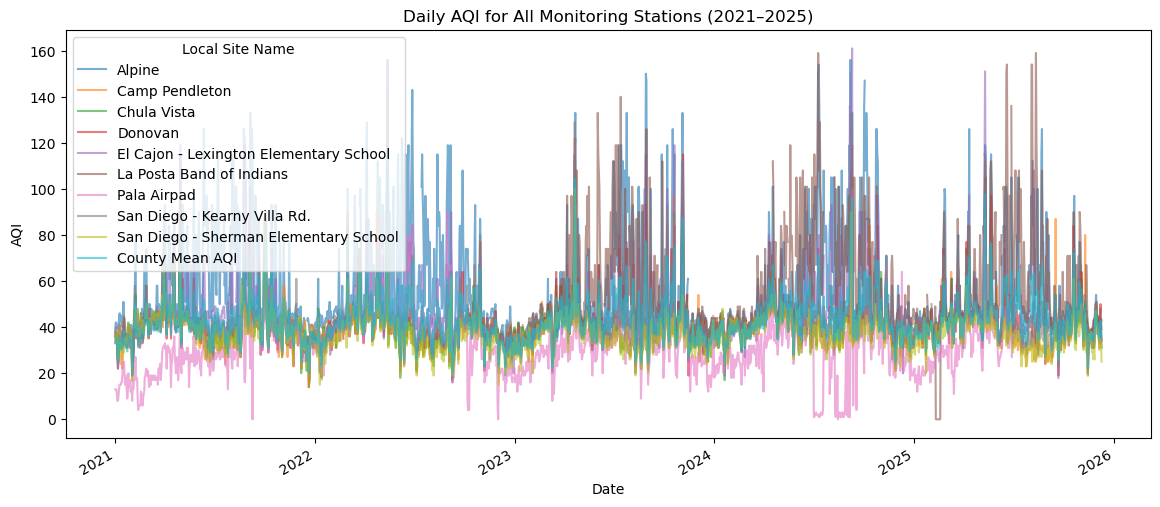

In [16]:
pivot.plot(figsize=(14,6), alpha=0.6)
plt.title("Daily AQI for All Monitoring Stations (2021–2025)")
plt.ylabel("AQI")

### Mean AQI By Month

<Axes: xlabel='Month'>

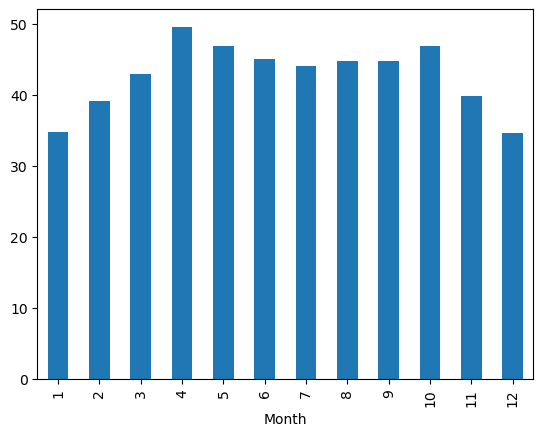

In [17]:
pivot['Month'] = pivot.index.month
pivot.groupby('Month')['County Mean AQI'].mean().plot(kind='bar')


In [18]:
pivot['7d'] = pivot['County Mean AQI'].rolling(7).mean()
pivot['30d'] = pivot['County Mean AQI'].rolling(30).mean()


In [19]:
heavy_days = pivot[pivot['County Mean AQI'] > 100]


In [20]:
coastal_stations = [
    "Chula Vista",
    "Camp Pendleton",
    "San Diego - Sherman Elementary School"
]


urban_stations = [
    "San Diego - Kearny Villa Rd.",
    "El Cajon - Lexington Elementary School",
    "Donovan"
]

inland_stations = [
    "Alpine",
    "Pala Airpad",
    "La Posta Band of Indians"
]

coastal = pivot[coastal_stations].mean(axis=1)
inland  = pivot[inland_stations].mean(axis=1)

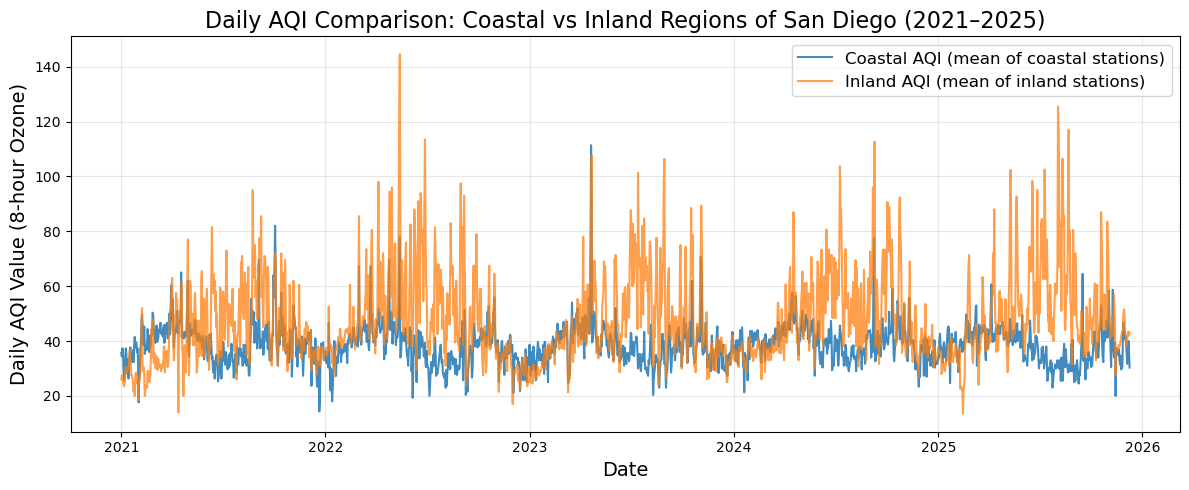

In [21]:
coastal_smooth = coastal.rolling(window=7, center=True).mean()
inland_smooth = inland.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))

plt.plot(coastal, label="Coastal AQI (mean of coastal stations)", alpha=0.85)
plt.plot(inland, label="Inland AQI (mean of inland stations)", alpha=0.75)

plt.title("Daily AQI Comparison: Coastal vs Inland Regions of San Diego (2021–2025)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily AQI Value (8-hour Ozone)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Coastal vs Urban Analysis (Including urban stations)

In [22]:
coastal_urban_stations = [
    'Chula Vista',
    'Camp Pendleton',
    'San Diego - Sherman Elementary School'
]

inland_urban_stations = [
    'Alpine',
    'Pala Airpad',
    'La Posta Band of Indians',
    'El Cajon - Lexington Elementary School',
    'Donovan'
]

coastal_urban = pivot[coastal_urban_stations].mean(axis=1)
inland_urban = pivot[inland_urban_stations].mean(axis=1)

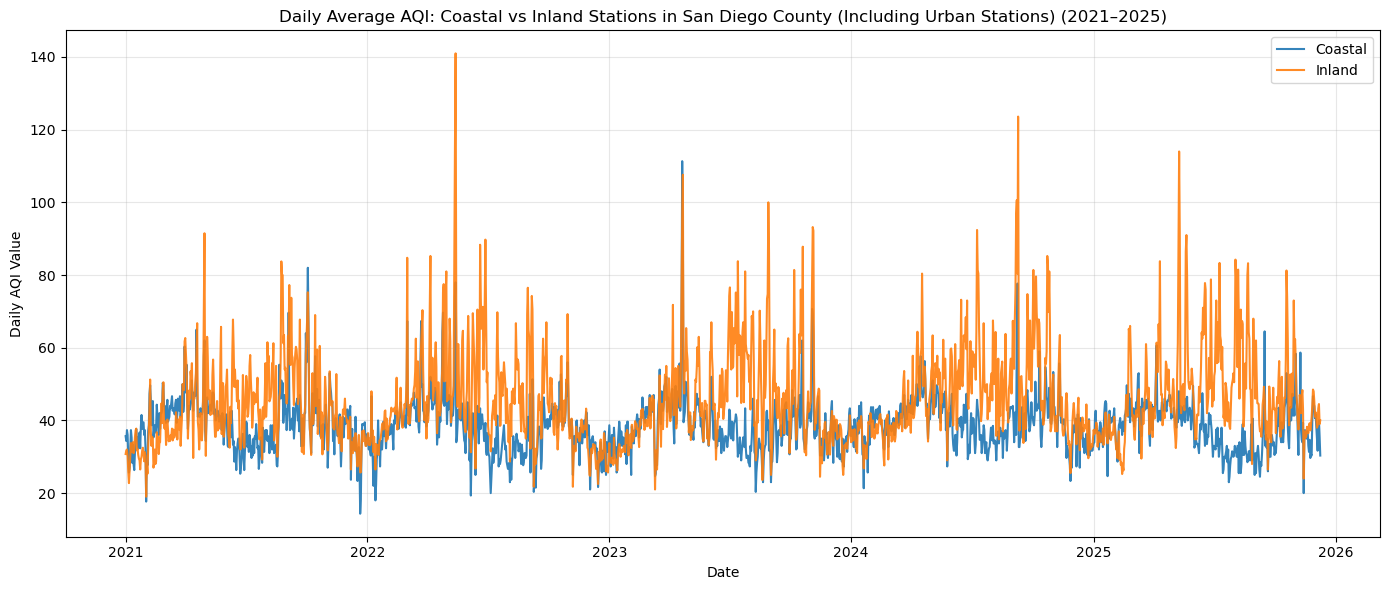

In [23]:
plt.figure(figsize=(14,6))
plt.plot(coastal_urban.index, coastal_urban, label="Coastal", alpha=0.9)
plt.plot(inland_urban.index, inland_urban, label="Inland", alpha=0.9)

plt.title("Daily Average AQI: Coastal vs Inland Stations in San Diego County (Including Urban Stations) (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Daily AQI Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
pivot.isna().sum().sort_values().drop(['County Mean AQI', 'Month', '7d', '30d'])

Local Site Name
San Diego - Sherman Elementary School      34
Alpine                                     39
San Diego - Kearny Villa Rd.               41
Donovan                                    53
Camp Pendleton                            119
Pala Airpad                               165
El Cajon - Lexington Elementary School    191
Chula Vista                               237
La Posta Band of Indians                  832
dtype: int64

In [25]:
monthly = pivot.resample('M').mean()
monthly = monthly.drop(columns=['County Mean AQI'])

C:\Users\diego\AppData\Local\Temp\ipykernel_31600\2948661079.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = pivot.resample('M').mean()


### Get Asthma Data

In [26]:
asthma = pd.read_csv('data/asthma.csv')

In [27]:
asthma.describe()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
count,12544.000000,12544.000000,12544.000000,12544.000000
mean,2017.927774,93220.995934,131.184471,40.267777
std,3.163016,1787.719672,133.187384,28.389523
min,2013.000000,90001.000000,12.000000,2.900000
25%,2015.000000,91915.000000,41.000000,21.400000
50%,2018.000000,93223.000000,85.000000,33.200000
75%,2021.000000,94931.000000,176.000000,50.700000
max,2023.000000,96161.000000,1130.000000,669.300000


In [28]:
asthma = asthma[(asthma['Year'] >= 2021) & (asthma['County'] == 'San Diego')]

In [29]:
asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.zfill(5)


In [30]:
asthma["Zip_Code"].unique()


array(['91901', '91902', '91906', '91910', '91911', '91913', '91914',
       '91915', '91932', '91935', '91941', '91942', '91945', '91950',
       '91977', '91978', '92008', '92009', '92010', '92011', '92019',
       '92020', '92021', '92024', '92025', '92026', '92027', '92028',
       '92029', '92040', '92054', '92056', '92057', '92058', '92064',
       '92065', '92069', '92071', '92078', '92081', '92082', '92083',
       '92084', '92101', '92102', '92103', '92104', '92105', '92106',
       '92107', '92108', '92109', '92110', '92111', '92113', '92114',
       '92115', '92116', '92117', '92118', '92119', '92120', '92122',
       '92123', '92124', '92126', '92127', '92128', '92129', '92130',
       '92131', '92139', '92154', '92173', '92036', '92037', '92003',
       '92007', '92014'], dtype=object)

In [31]:
asthma.isna().sum()

Year                                0
Zip_Code                            0
Number_of_Asthma_ED_Visits          0
Age_Adjusted_Rate_of_Asthma_ED_V    0
Age_Group                           0
County                              0
dtype: int64

In [32]:
asthma['Zip_Code'].nunique()

79

### Merge Asthma and Demographics Data

In [33]:
demo = pd.read_csv('data/demographics_zipcode.csv')

In [34]:
demo.columns

Index(['pop_total', 'med_income', 'med_age', 'white_alone', 'black_alone',
       'asian_alone', 'hispanic_any', 'pop_below_poverty', 'NAME', 'Zip_Code',
       'p_white', 'p_black', 'p_asian', 'p_hispanic', 'p_poverty'],
      dtype='object')

In [35]:
asthma = asthma.copy()
demo = demo.copy()

asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.strip().str.zfill(5)
demo["Zip_Code"] = demo["Zip_Code"].astype(str).str.strip().str.zfill(5)

asthma_zips = set(asthma["Zip_Code"].unique())
demo_zips = set(demo["Zip_Code"].unique())

print("Asthma ZIPs:", len(asthma_zips))
print("Census ZIPs:", len(demo_zips))
print("Asthma ZIPs missing census data:", len(asthma_zips - demo_zips))

Asthma ZIPs: 79
Census ZIPs: 83
Asthma ZIPs missing census data: 0


In [36]:
merged = asthma.merge(
    demo,
    on="Zip_Code",
    how="left",
    validate="many_to_one"
)

assert merged.shape[0] == asthma.shape[0]
merged.head()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V,Age_Group,County,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,NAME,p_white,p_black,p_asian,p_hispanic,p_poverty
0,2021,91901,48,33.0,All Ages,San Diego,18300.0,116600.0,42.5,14504.0,310.0,474.0,3397.0,1845.0,ZCTA5 91901,0.792568,0.016940,0.025902,0.185628,0.100820
1,2021,91902,22,14.3,All Ages,San Diego,17445.0,121727.0,46.9,7318.0,255.0,2578.0,8241.0,1017.0,ZCTA5 91902,0.419490,0.014617,0.147779,0.472399,0.058298
2,2021,91906,14,38.7,All Ages,San Diego,3375.0,58561.0,44.9,2235.0,204.0,15.0,1016.0,507.0,ZCTA5 91906,0.662222,0.060444,0.004444,0.301037,0.150222
3,2021,91910,187,24.4,All Ages,San Diego,77957.0,87705.0,38.4,28568.0,2888.0,8215.0,50129.0,7978.0,ZCTA5 91910,0.366458,0.037046,0.105379,0.643034,0.102338
4,2021,91911,215,24.5,All Ages,San Diego,84619.0,79334.0,36.7,28566.0,3447.0,6106.0,63244.0,8862.0,ZCTA5 91911,0.337584,0.040736,0.072159,0.747397,0.104728


In [37]:
merged.columns

Index(['Year', 'Zip_Code', 'Number_of_Asthma_ED_Visits',
       'Age_Adjusted_Rate_of_Asthma_ED_V', 'Age_Group', 'County', 'pop_total',
       'med_income', 'med_age', 'white_alone', 'black_alone', 'asian_alone',
       'hispanic_any', 'pop_below_poverty', 'NAME', 'p_white', 'p_black',
       'p_asian', 'p_hispanic', 'p_poverty'],
      dtype='object')

<Axes: xlabel='Age_Adjusted_Rate_of_Asthma_ED_V', ylabel='Count'>

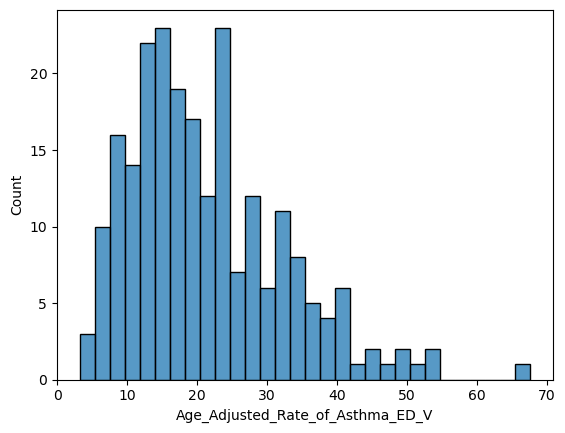

In [38]:
sns.histplot(merged["Age_Adjusted_Rate_of_Asthma_ED_V"], bins=30)

In [39]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

In [40]:
df.head(10)

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,2021-01-01,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
1,2021-01-02,AQS,60730001,1,0.038,ppm,35,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
2,2021-01-03,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
3,2021-01-04,AQS,60730001,1,0.039,ppm,36,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
4,2021-01-05,AQS,60730001,1,0.034,ppm,31,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
5,2021-01-06,AQS,60730001,1,0.028,ppm,26,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
6,2021-01-07,AQS,60730001,1,0.031,ppm,29,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
7,2021-01-08,AQS,60730001,1,0.036,ppm,33,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
8,2021-01-09,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
9,2021-01-10,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088


In [41]:
df['Local Site Name'].unique()

array(['Chula Vista', 'Alpine', 'Camp Pendleton', 'Donovan',
       'San Diego - Kearny Villa Rd.',
       'El Cajon - Lexington Elementary School',
       'San Diego - Sherman Elementary School', 'Pala Airpad',
       'La Posta Band of Indians'], dtype=object)

### Assign each zipcode to the closest AQI measuring station

In [47]:
demo["Zip_Code"] = demo["Zip_Code"].astype(str).str.strip().str.zfill(5)
asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.strip().str.zfill(5)

# Only need centroids for ZIPs you actually have
zips = sorted(asthma["Zip_Code"].unique())

nomi = pgeocode.Nominatim("us")
geo = nomi.query_postal_code(zips)

zip_points = pd.DataFrame({
    "Zip_Code": zips,
    "centroid_lat": geo["latitude"].values,
    "centroid_lon": geo["longitude"].values
}).dropna(subset=["centroid_lat", "centroid_lon"])

print("ZIPs needed:", len(zips))
print("ZIPs with centroids found:", zip_points["Zip_Code"].nunique())
zip_points.head()

ZIPs needed: 79
ZIPs with centroids found: 79


,Zip_Code,centroid_lat,centroid_lon
0,91901,32.8282,-116.7543
1,91902,32.6671,-117.0221
2,91906,32.6605,-116.4905
3,91910,32.6371,-117.0676
4,91911,32.6084,-117.0565


In [49]:
aqi_stations = (
    df[["Site ID", "Local Site Name", "Site Latitude", "Site Longitude"]]
    .drop_duplicates()
    .rename(columns={
        "Site Latitude": "station_lat",
        "Site Longitude": "station_lon",
        "Local Site Name": "station_name",
        "Site ID": "station_id"
    })
    .reset_index(drop=True)
)

aqi_stations

,station_id,station_name,station_lat,station_lon
0,60730001,Chula Vista,32.631242,-117.059088
1,60731006,Alpine,32.842318,-116.768293
2,60731008,Camp Pendleton,33.217046,-117.396249
3,60731014,Donovan,32.578165,-116.921374
4,60731016,San Diego - Kearny Villa Rd.,32.845709,-117.123964
5,60731022,El Cajon - Lexington Elementary School,32.789565,-116.944308
6,60731026,San Diego - Sherman Elementary School,32.710177,-117.142665
7,60731201,Pala Airpad,33.362593,-117.090230
8,60739991,La Posta Band of Indians,32.725189,-116.364410


In [50]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

zip_points["_k"] = 1
aqi_stations["_k"] = 1
pairs = zip_points.merge(aqi_stations, on="_k").drop(columns="_k")

pairs["dist_km"] = haversine_km(
    pairs["centroid_lat"], pairs["centroid_lon"],
    pairs["station_lat"], pairs["station_lon"]
)

zip_to_station = (
    pairs.sort_values("dist_km")
         .groupby("Zip_Code", as_index=False)
         .first()[["Zip_Code", "station_id", "station_name", "dist_km"]]
)

zip_to_station.head()

,Zip_Code,station_id,station_name,dist_km
0,91901,60731006,Alpine,2.042945
1,91902,60730001,Chula Vista,5.281132
2,91906,60739991,La Posta Band of Indians,13.819061
3,91910,60730001,Chula Vista,1.029376
4,91911,60730001,Chula Vista,2.551453


In [51]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

station_year_aqi = (
    df.rename(columns={"Site ID": "station_id"})
      .groupby(["station_id", "Year"], as_index=False)["Daily AQI Value"]
      .mean()
      .rename(columns={"Daily AQI Value": "mean_aqi"})
)

station_year_aqi.head()

,station_id,Year,mean_aqi
0,60730001,2021,40.125698
1,60730001,2022,38.488506
2,60730001,2023,38.827298
3,60730001,2024,40.452722
4,60730001,2025,41.510067


In [54]:
station_year_aqi["Year"].min(), station_year_aqi["Year"].max()
station_year_aqi["station_id"].nunique()

9

In [55]:
zip_year_aqi = zip_to_station.merge(station_year_aqi, on="station_id", how="left")
zip_year_aqi.head()

,Zip_Code,station_id,station_name,dist_km,Year,mean_aqi
0,91901,60731006,Alpine,2.042945,2021,58.421348
1,91901,60731006,Alpine,2.042945,2022,59.253521
2,91901,60731006,Alpine,2.042945,2023,55.456825
3,91901,60731006,Alpine,2.042945,2024,58.446629
4,91901,60731006,Alpine,2.042945,2025,52.620896


In [56]:
zip_year_aqi.isna().sum().head()

Zip_Code        0
station_id      0
station_name    0
dist_km         0
Year            0
dtype: int64

In [57]:
final = merged.merge(
    zip_year_aqi[["Zip_Code", "Year", "mean_aqi", "station_name", "dist_km"]],
    on=["Zip_Code", "Year"],
    how="left",
    validate="many_to_one"
)

assert final.shape[0] == merged.shape[0]
final[["Zip_Code", "Year", "mean_aqi", "station_name", "dist_km"]].head()

,Zip_Code,Year,mean_aqi,station_name,dist_km
0,91901,2021,58.421348,Alpine,2.042945
1,91902,2021,40.125698,Chula Vista,5.281132
2,91906,2021,NaN,NaN,NaN
3,91910,2021,40.125698,Chula Vista,1.029376
4,91911,2021,40.125698,Chula Vista,2.551453


In [62]:
# Drop missing values because there are very few of them and correspond to very rural and uninhabited zip codes in eastern SD county
model_df = final.dropna(subset=["mean_aqi"]).copy()

In [63]:
model_df.columns

Index(['Year', 'Zip_Code', 'Number_of_Asthma_ED_Visits',
       'Age_Adjusted_Rate_of_Asthma_ED_V', 'Age_Group', 'County', 'pop_total',
       'med_income', 'med_age', 'white_alone', 'black_alone', 'asian_alone',
       'hispanic_any', 'pop_below_poverty', 'NAME', 'p_white', 'p_black',
       'p_asian', 'p_hispanic', 'p_poverty', 'mean_aqi', 'station_name',
       'dist_km'],
      dtype='object')

<Axes: xlabel='mean_aqi', ylabel='Age_Adjusted_Rate_of_Asthma_ED_V'>

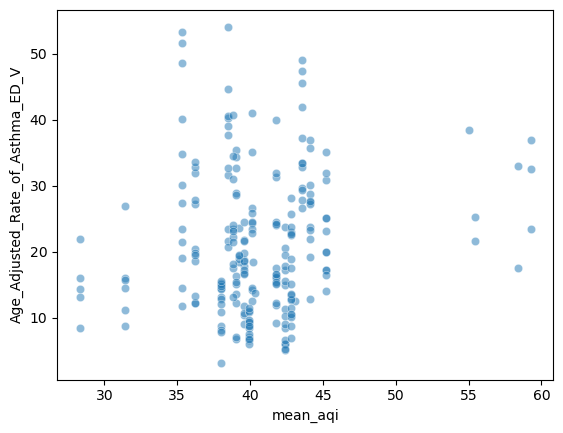

In [64]:
sns.scatterplot(
    data=model_df,
    x="mean_aqi",
    y="Age_Adjusted_Rate_of_Asthma_ED_V",
    alpha=0.5
)

In [74]:

model = smf.ols(
    "Age_Adjusted_Rate_of_Asthma_ED_V ~ mean_aqi + med_income + p_poverty + p_hispanic + p_black + Year",
    data=model_df
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     Age_Adjusted_Rate_of_Asthma_ED_V   R-squared:                       0.551
Model:                                          OLS   Adj. R-squared:                  0.539
Method:                               Least Squares   F-statistic:                     44.81
Date:                              Fri, 12 Dec 2025   Prob (F-statistic):           1.54e-35
Time:                                      04:08:40   Log-Likelihood:                -762.13
No. Observations:                               226   AIC:                             1538.
Df Residuals:                                   219   BIC:                             1562.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1416.1315   1180.569     -1.200      0.232   -3742.863     910.600
mean_aqi       0.5480      0.107      5.128      0.000       0.337       0.759
med_income -6.046e-05   2.76e-05     -2.193      0.029      -0.000   -6.13e-06
p_poverty     54.5790     16.689      3.270      0.001      21.688      87.470
p_hispanic     6.9976      3.436      2.036      0.043       0.226      13.770
p_black      121.2718     14.761      8.216      0.000      92.180     150.364
Year           0.6966      0.584      1.193      0.234      -0.454       1.847
==============================================================================
Omnibus:                        7.328   Durbin-Watson:                   1.319
Prob(Omnibus):                  0.026   Jarque-Bera (JB):                7.208
Skew:                           0.373   Prob(JB):                       0.0272
Kurtosis:                       3.458   Cond. No.                     2.78e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [69]:
model_df.columns

Index(['Year', 'Zip_Code', 'Number_of_Asthma_ED_Visits',
       'Age_Adjusted_Rate_of_Asthma_ED_V', 'Age_Group', 'County', 'pop_total',
       'med_income', 'med_age', 'white_alone', 'black_alone', 'asian_alone',
       'hispanic_any', 'pop_below_poverty', 'NAME', 'p_white', 'p_black',
       'p_asian', 'p_hispanic', 'p_poverty', 'mean_aqi', 'station_name',
       'dist_km'],
      dtype='object')